# Parte 2 – Caso Real: Preparación de Datos con CRISP-DM


## a) Comprensión del negocio – CRISP-DM

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

## b) Comprensión de datos – Análisis Exploratorio (AED)

In [2]:
# Carga del dataset completo
df_accidents = pd.read_csv(
    './dataset/accidents.csv',
    na_values=[' ', '', 'NA', 'NULL', 'NaN']
)
# Valores faltantes codificados como \N en el origen (backslash + N)
missing_marker = chr(92) + 'N'
df_accidents = df_accidents.replace(missing_marker, np.nan)

df_gemeenten = pd.read_csv('./dataset/gemeenten.csv')
df_infra = pd.read_csv('./dataset/cycling_infrastructure_osm.csv')
df_weather_stations = pd.read_csv('./dataset/weather_stations.csv')
df_weather_daily = pd.read_csv('./dataset/weather_daily.csv', low_memory=False)
df_weather_daily = df_weather_daily.replace(missing_marker, np.nan)

In [3]:
df_accidents.head(10)

,accident_id,year,severity_raw,party_count,party1_type,party2_type,accident_type,road_situation,speed_limit_kmh,road_lighting,light_condition_label,weather_raw,infra_type,road_segment_id,street_name,place_name,gemeente_name_raw,province,alcohol_indicated,latitude,longitude,severity_label,severity_code,weather_label,built_up_area,cyclists_involved,gemeente_code
0,20220006279,2022,Letsel,2,Personenauto,Fiets,Flank,"Kruispunt, 4 takken",30,Niet brandend,Daglicht,Droog,NaN,NaN,Eekhoornveld,Zwolle,Zwolle,Overijssel,False,52.493475,6.099772,injury,2,clear,False,1,GM0193
1,20230000166,2023,Letsel,2,Personenauto,Fiets,Flank,Rotonde,50,Niet brandend,Daglicht,Regen,NaN,NaN,Deventerweg,Harderwijk,Harderwijk,Gelderland,False,52.335805,5.634966,injury,2,rain,False,1,GM0243
2,20220053267,2022,Uitsluitend materiele schade,2,Personenauto,e-bike,Flank,Rotonde,50,Niet brandend,Daglicht,Droog,NaN,NaN,Marconistraat,Heerhugowaard,Dijk en Waard,Noord-Holland,False,52.684566,4.834162,material damage only,4,clear,False,1,GM1980
3,20220053872,2022,Letsel,2,Fiets,Personenauto,Flank,Rotonde,50,Niet brandend,Daglicht,Droog,NaN,NaN,Verspronckweg,Haarlem,Haarlem,Noord-Holland,False,52.391402,4.625152,injury,2,clear,False,1,GM0392
4,20220126544,2022,Letsel,2,Bromfiets,Fiets,Flank,"Kruispunt, 4 takken",NaN,Niet brandend,Daglicht,Droog,NaN,NaN,Prinses Beatrixlaan,Rijswijk,Rijswijk,Zuid-Holland,False,52.042711,4.308355,injury,2,clear,False,1,NaN
5,20220128864,2022,Letsel,2,Personenauto,Fiets,Flank,"Kruispunt, 4 takken",30,Niet brandend,Daglicht,Droog,NaN,NaN,Willem Passtoorsstraat,Schiedam,Schiedam,Zuid-Holland,False,51.924654,4.394976,injury,2,clear,False,1,GM0606
6,20220116779,2022,Letsel,3,Fiets,Fiets,Onbekend,Rotonde,30,Niet aanwezig,Daglicht,Droog,NaN,NaN,Fort,Zaltbommel,Zaltbommel,Gelderland,False,51.804963,5.232114,injury,2,clear,False,1,GM0297
7,20220103290,2022,Letsel,2,Personenauto,Fiets,Flank,"Kruispunt, 4 takken",50,Brandend,Duisternis,Droog,NaN,NaN,Van Woustraat,Amsterdam,Amsterdam,Noord-Holland,False,52.357735,4.899323,injury,2,clear,False,1,GM0363
8,20240004088,2024,Letsel,2,Fiets,Fiets,Frontaal,Rechte weg,80,Niet aanwezig,Duisternis,Droog,NaN,600239451,Heetenseweg,Heeten,Raalte,Overijssel,False,52.350183,6.272996,injury,2,clear,False,1,GM0177
9,20220137188,2022,Dodelijk,2,Bromfiets,Fiets,Flank,"Kruispunt, 3 takken",NaN,Niet brandend,Daglicht,Droog,NaN,NaN,Spoordijkstraat,Enschede,Enschede,Overijssel,True,52.221346,6.869763,fatal,1,clear,False,1,GM0153


In [4]:
df_accidents.shape

(56743, 27)

In [5]:
df_accidents.dtypes

accident_id                int64
year                       int64
severity_raw              object
party_count                int64
party1_type               object
party2_type               object
accident_type             object
road_situation            object
speed_limit_kmh           object
road_lighting             object
light_condition_label     object
weather_raw               object
infra_type                object
road_segment_id           object
street_name               object
place_name                object
gemeente_name_raw         object
province                  object
alcohol_indicated           bool
latitude                 float64
longitude                float64
severity_label            object
severity_code              int64
weather_label             object
built_up_area               bool
cyclists_involved          int64
gemeente_code             object
dtype: object

### Variables relevantes

| Grupo | Columnas |
|-------|----------|
| Severidad | `severity_label`, `severity_code`, `severity_raw` |
| Temporal | `year` |
| Vía | `accident_type`, `road_situation`, `speed_limit_kmh` |
| Entorno | `road_lighting`, `light_condition_label`, `weather_label` |
| Geografía | `province`, `gemeente_code`, `latitude`, `longitude` |
| Clima (estaciones) | `weather_temp_mean_c`, `weather_precip_mm_total`, `weather_wind_mean_ms`, ... (desde `weather_daily`) |
| Clima (accidente) | `weather_label` (one-hot en tabla minable) |

In [6]:
# Valores nulos por columna
df_accidents.isnull().sum().sort_values(ascending=False)

infra_type               54748
road_segment_id          33045
party2_type               8455
weather_raw               3371
speed_limit_kmh           3261
road_lighting             2723
road_situation            2359
gemeente_code             1118
party1_type                362
accident_type                0
alcohol_indicated            0
cyclists_involved            0
built_up_area                0
weather_label                0
severity_code                0
severity_label               0
longitude                    0
latitude                     0
province                     0
gemeente_name_raw            0
place_name                   0
street_name                  0
year                         0
severity_raw                 0
party_count                  0
light_condition_label        0
accident_id                  0
dtype: int64

In [7]:
df_accidents.describe(include='all')

,accident_id,year,severity_raw,party_count,party1_type,party2_type,accident_type,road_situation,speed_limit_kmh,road_lighting,light_condition_label,weather_raw,infra_type,road_segment_id,street_name,place_name,gemeente_name_raw,province,alcohol_indicated,latitude,longitude,severity_label,severity_code,weather_label,built_up_area,cyclists_involved,gemeente_code
count,5.674300e+04,56743.000000,56743,56743.000000,56381,48288,56743,54384,53482,54020,56743,53372,1995,23698,56743,56743,56743,56743,56743,56743.000000,56743.000000,56743,56743.000000,56743,56743,56743.0,55625
unique,NaN,NaN,3,NaN,21,23,10,7,8,3,3,13,6,20804,19749,1851,342,12,2,NaN,NaN,3,NaN,4,1,NaN,334
top,NaN,NaN,Letsel,NaN,Personenauto,Fiets,Flank,Rechte weg,50,Niet brandend,Daglicht,Droog,Brug/viaduct,242376103,FIETSPAD,Amsterdam,Amsterdam,Zuid-Holland,False,NaN,NaN,injury,NaN,clear,False,NaN,GM0363
freq,NaN,NaN,30334,NaN,24948,37577,26845,21353,28934,41282,45387,46163,690,15,717,3931,3981,17042,56069,NaN,NaN,30334,NaN,46163,56743,NaN,3981
mean,2.023033e+10,2023.024073,NaN,1.939993,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,52.105177,5.161023,NaN,2.900534,NaN,NaN,1.0,NaN
std,8.142744e+06,0.816768,NaN,0.484009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.461685,0.758699,NaN,1.010158,NaN,NaN,0.0,NaN
min,2.022000e+10,2022.000000,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50.760362,3.376028,NaN,1.000000,NaN,NaN,1.0,NaN
25%,2.022020e+10,2022.000000,NaN,2.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,51.886876,4.526212,NaN,2.000000,NaN,NaN,1.0,NaN
50%,2.023006e+10,2023.000000,NaN,2.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,52.086812,4.930199,NaN,2.000000,NaN,NaN,1.0,NaN
75%,2.024004e+10,2024.000000,NaN,2.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,52.358112,5.712950,NaN,4.000000,NaN,NaN,1.0,NaN


### Análisis univariado

In [8]:
df_accidents['severity_label'].value_counts(normalize=True).mul(100).round(2)

severity_label
injury                  53.46
material damage only    45.53
fatal                    1.01
Name: proportion, dtype: float64

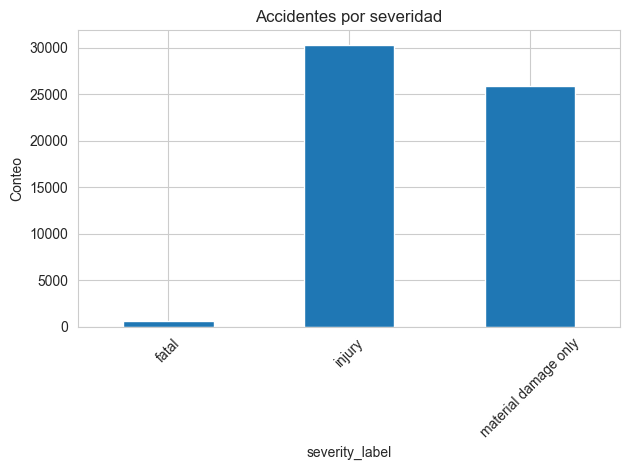

In [9]:
df_accidents.groupby('severity_label').size().plot.bar(title='Accidentes por severidad')
plt.ylabel('Conteo')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

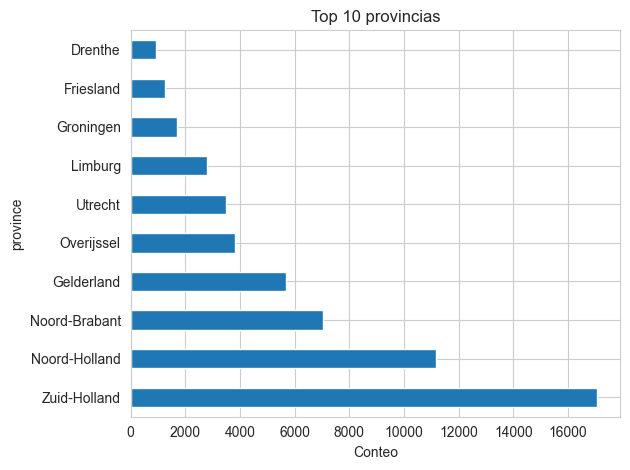

In [10]:
df_accidents['province'].value_counts().head(10).plot.barh(title='Top 10 provincias')
plt.xlabel('Conteo')
plt.tight_layout()
plt.show()

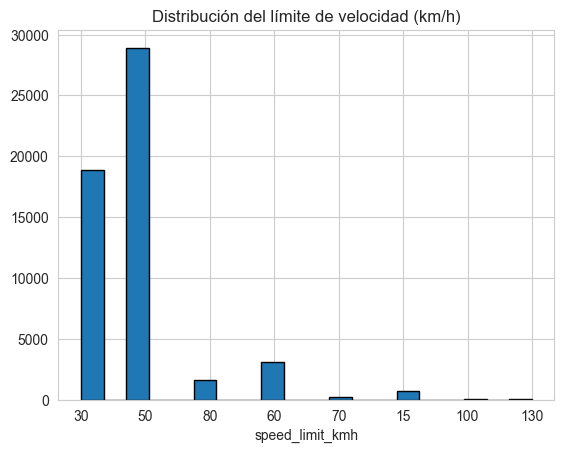

In [11]:
df_accidents['speed_limit_kmh'].hist(bins=20, edgecolor='black')
plt.title('Distribución del límite de velocidad (km/h)')
plt.xlabel('speed_limit_kmh')
plt.show()

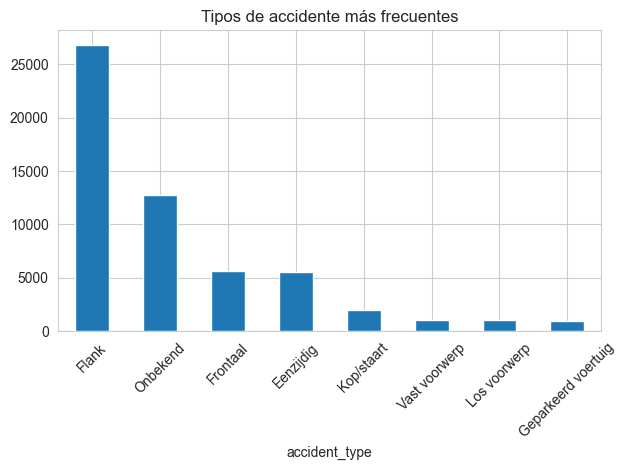

In [12]:
df_accidents.groupby('accident_type').size().sort_values(ascending=False).head(8).plot.bar()
plt.title('Tipos de accidente más frecuentes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Análisis bivariado

In [13]:
pd.crosstab(
    df_accidents['severity_label'],
    df_accidents['weather_label'],
    normalize='index'
).round(3)

weather_label,clear,fog,rain,unknown
severity_label,,,,
fatal,0.888,0.003,0.068,0.040
injury,0.815,0.002,0.109,0.074
material damage only,0.810,0.003,0.127,0.059


In [14]:
pd.crosstab(
    df_accidents['severity_label'],
    df_accidents['light_condition_label'],
    normalize='index'
).round(3)

light_condition_label,Daglicht,Duisternis,Schemer
severity_label,,,
fatal,0.822,0.152,0.026
injury,0.795,0.161,0.045
material damage only,0.805,0.146,0.049


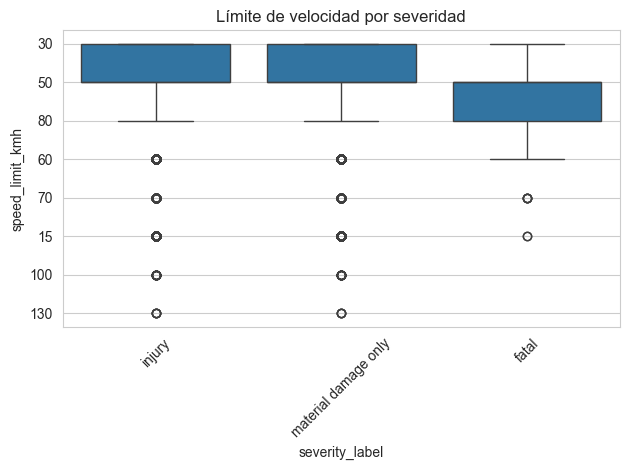

In [15]:
sns.boxplot(data=df_accidents, x='severity_label', y='speed_limit_kmh')
plt.title('Límite de velocidad por severidad')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [16]:
df_accidents.groupby(['province', 'severity_label']).size().unstack(fill_value=0).head(10)

severity_label,fatal,injury,material damage only
province,,,
Drenthe,21,590,313
Flevoland,6,251,653
Friesland,26,732,491
Gelderland,91,2290,3300
Groningen,24,1147,539
Limburg,45,850,1900
Noord-Brabant,97,2419,4534
Noord-Holland,93,5819,5270
Overijssel,49,1701,2079


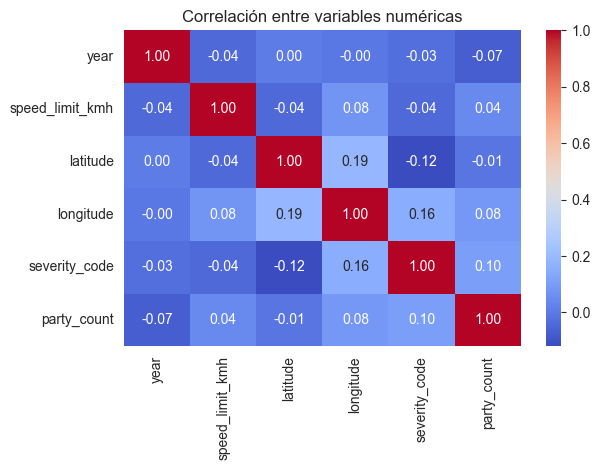

In [17]:
cols_num = ['year', 'speed_limit_kmh', 'latitude', 'longitude', 'severity_code', 'party_count']
sns.heatmap(df_accidents[cols_num].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlación entre variables numéricas')
plt.tight_layout()
plt.show()

### Perfilado con ydata_profiling

In [18]:
# !pip install ydata-profiling

In [19]:
from ydata_profiling import ProfileReport

profile = ProfileReport(df_accidents, title='Profiling - Accidentes ciclistas (dataset completo)')

C:\Users\PC\AppData\Local\Temp\ipykernel_1628\3615012169.py:1: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


In [20]:
profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████████████████████████████████████████████████████████████████████████████| 27/27 [00:01<00:00, 17.17it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

## c) Preparación de datos por columnas

Operaciones en esta sección:
0. **Detección de nulos**: eliminar columnas con más del 60% de valores faltantes
1. Conversión de tipos de datos
2. Imputación de valores faltantes
3. Creación y transformación de columnas (`periodo_luz`, etc.)
4. **Integración de clima** (`weather_daily` + `weather_stations`) y merge con `gemeenten` e infraestructura

> Regla: evaluar % nulos **antes** de imputar. Si supera 60%, se elimina (no se rellena para ocultarlo).
> Las columnas `weather_*` del merge municipal tienen ~91% nulos → se eliminan. No se usa imputación nacional.

In [21]:
UMBRAL_NULOS = 0.60  # 60%

def eliminar_columnas_alto_nulo(df, umbral=UMBRAL_NULOS, excluir=None):
    """Elimina columnas cuyo % de nulos supera el umbral."""
    excluir = excluir or []
    pct_nulos = df.isnull().mean()
    cols_eliminar = [c for c in pct_nulos[pct_nulos > umbral].index if c not in excluir]
    if cols_eliminar:
        print(f'Columnas eliminadas (>{int(umbral * 100)}% nulos):')
        for col in cols_eliminar:
            print(f'  - {col}: {pct_nulos[col] * 100:.2f}%')
        df = df.drop(columns=cols_eliminar)
    else:
        print(f'Sin columnas por encima del {int(umbral * 100)}% de nulos')
    return df

# Paso 0: descartar columnas con demasiados nulos antes de procesar
cols_protegidas = ['severity_label', 'severity_code', 'severity_raw']
df_accidents = eliminar_columnas_alto_nulo(df_accidents, excluir=cols_protegidas)

df_prep = df_accidents.copy()
df_prep.head()

Columnas eliminadas (>60% nulos):
  - infra_type: 96.48%


,accident_id,year,severity_raw,party_count,party1_type,party2_type,accident_type,road_situation,speed_limit_kmh,road_lighting,light_condition_label,weather_raw,road_segment_id,street_name,place_name,gemeente_name_raw,province,alcohol_indicated,latitude,longitude,severity_label,severity_code,weather_label,built_up_area,cyclists_involved,gemeente_code
0,20220006279,2022,Letsel,2,Personenauto,Fiets,Flank,"Kruispunt, 4 takken",30,Niet brandend,Daglicht,Droog,NaN,Eekhoornveld,Zwolle,Zwolle,Overijssel,False,52.493475,6.099772,injury,2,clear,False,1,GM0193
1,20230000166,2023,Letsel,2,Personenauto,Fiets,Flank,Rotonde,50,Niet brandend,Daglicht,Regen,NaN,Deventerweg,Harderwijk,Harderwijk,Gelderland,False,52.335805,5.634966,injury,2,rain,False,1,GM0243
2,20220053267,2022,Uitsluitend materiele schade,2,Personenauto,e-bike,Flank,Rotonde,50,Niet brandend,Daglicht,Droog,NaN,Marconistraat,Heerhugowaard,Dijk en Waard,Noord-Holland,False,52.684566,4.834162,material damage only,4,clear,False,1,GM1980
3,20220053872,2022,Letsel,2,Fiets,Personenauto,Flank,Rotonde,50,Niet brandend,Daglicht,Droog,NaN,Verspronckweg,Haarlem,Haarlem,Noord-Holland,False,52.391402,4.625152,injury,2,clear,False,1,GM0392
4,20220126544,2022,Letsel,2,Bromfiets,Fiets,Flank,"Kruispunt, 4 takken",NaN,Niet brandend,Daglicht,Droog,NaN,Prinses Beatrixlaan,Rijswijk,Rijswijk,Zuid-Holland,False,52.042711,4.308355,injury,2,clear,False,1,NaN


### Conversión de tipos de datos

In [22]:
df_prep['year'] = df_prep['year'].astype('int64')
df_prep['speed_limit_kmh'] = pd.to_numeric(df_prep['speed_limit_kmh'], errors='coerce')
df_prep['severity_code'] = pd.to_numeric(df_prep['severity_code'], errors='coerce')
df_prep['severity_label'] = df_prep['severity_label'].astype('category')
df_prep['province'] = df_prep['province'].astype('category')
df_prep['accident_type'] = df_prep['accident_type'].astype('category')
df_prep['alcohol_indicated'] = df_prep['alcohol_indicated'].astype('bool')
df_prep['built_up_area'] = df_prep['built_up_area'].astype('bool')
df_prep['cyclists_involved'] = df_prep['cyclists_involved'].astype('int64')

df_prep.dtypes

accident_id                 int64
year                        int64
severity_raw               object
party_count                 int64
party1_type                object
party2_type                object
accident_type            category
road_situation             object
speed_limit_kmh           float64
road_lighting              object
light_condition_label      object
weather_raw                object
road_segment_id            object
street_name                object
place_name                 object
gemeente_name_raw          object
province                 category
alcohol_indicated            bool
latitude                  float64
longitude                 float64
severity_label           category
severity_code               int64
weather_label              object
built_up_area                bool
cyclists_involved           int64
gemeente_code              object
dtype: object

### Imputación de valores faltantes

In [23]:

mediana_vel = df_prep['speed_limit_kmh'].median()
df_prep['speed_limit_kmh'] = df_prep['speed_limit_kmh'].fillna(mediana_vel)


df_prep['weather_label'] = df_prep['weather_label'].fillna('unknown')

df_prep.isnull().sum().sort_values(ascending=False).head(10)

road_segment_id      33045
party2_type           8455
weather_raw           3371
road_lighting         2723
road_situation        2359
gemeente_code         1118
party1_type            362
province                 0
cyclists_involved        0
built_up_area            0
dtype: int64

### Creación y transformación de columnas

In [24]:
def clasificar_luz(valor):
    if pd.isna(valor):
        return 'otro'
    valor = str(valor).lower()
    if 'dag' in valor or 'day' in valor:
        return 'dia'
    if 'duist' in valor or 'dark' in valor or 'nacht' in valor:
        return 'noche'
    return 'otro'

df_prep['periodo_luz'] = df_prep['light_condition_label'].apply(clasificar_luz)
df_prep['periodo'] = df_prep['year'].astype(str)
df_prep['periodo'] = df_prep['periodo'].astype('category')

df_prep[['severity_label', 'severity_code', 'periodo_luz', 'periodo']].head(10)

,severity_label,severity_code,periodo_luz,periodo
0,injury,2,dia,2022
1,injury,2,dia,2023
2,material damage only,4,dia,2022
3,injury,2,dia,2022
4,injury,2,dia,2022
5,injury,2,dia,2022
6,injury,2,dia,2022
7,injury,2,noche,2022
8,injury,2,noche,2024
9,fatal,1,dia,2022


### Integración de clima (`weather_daily` + `weather_stations`)

1. Agregar métricas diarias por **estación** y **año**.
2. Vincular estación al municipio más cercano (`nearest_gemeente_code`).
3. Promediar por `gemeente_code` + `year` si hay varias estaciones.
4. Rellenar municipios sin estación con el **promedio nacional anual** (mismo año).

In [25]:
# Auditoría: columnas weather de gemeente_yearly_summary (no se integran al superar 60% nulos)
df_gys = pd.read_csv('./dataset/gemeente_yearly_summary.csv')
cols_gys_weather = [c for c in df_gys.columns if c.startswith('weather_')]
pct_gys = df_gys[cols_gys_weather].isnull().mean()
cols_gys_rechazadas = pct_gys[pct_gys > UMBRAL_NULOS].sort_values(ascending=False)
print('gemeente_yearly_summary - columnas weather NO integradas (>60% nulos):')
for col, pct in cols_gys_rechazadas.items():
    print(f'  - {col}: {pct * 100:.2f}%')

weather_numeric_cols = [
    'temp_mean_c', 'temp_min_c', 'temp_max_c', 'precip_mm',
    'wind_mean_ms', 'sunshine_hours', 'humidity_pct', 'pressure_hpa'
]

for col in weather_numeric_cols:
    df_weather_daily[col] = pd.to_numeric(df_weather_daily[col], errors='coerce')

df_weather_daily['date'] = pd.to_datetime(df_weather_daily['date'])
df_weather_daily['year'] = df_weather_daily['date'].dt.year
df_weather_daily['station_id'] = df_weather_daily['station_id'].astype(int)
df_weather_stations['station_id'] = df_weather_stations['station_id'].astype(int)

weather_agg = {
    'weather_temp_mean_c': ('temp_mean_c', 'mean'),
    'weather_temp_min_c': ('temp_min_c', 'mean'),
    'weather_temp_max_c': ('temp_max_c', 'mean'),
    'weather_precip_mm_total': ('precip_mm', 'sum'),
    'weather_wind_mean_ms': ('wind_mean_ms', 'mean'),
    'weather_sunshine_hours_total': ('sunshine_hours', 'sum'),
    'weather_humidity_mean_pct': ('humidity_pct', 'mean'),
    'weather_pressure_mean_hpa': ('pressure_hpa', 'mean'),
}

weather_feature_cols = list(weather_agg.keys())

weather_anual_estacion = (
    df_weather_daily.groupby(['station_id', 'year'])
    .agg(**weather_agg)
    .reset_index()
)

weather_anual_gemeente = (
    weather_anual_estacion
    .merge(df_weather_stations[['station_id', 'nearest_gemeente_code']], on='station_id')
    .groupby(['nearest_gemeente_code', 'year'])[weather_feature_cols]
    .mean()
    .reset_index()
    .rename(columns={'nearest_gemeente_code': 'gemeente_code'})
)

weather_anual_nacional = (
    df_weather_daily.groupby('year')
    .agg(**weather_agg)
    .reset_index()
)

weather_anual_gemeente.head()

gemeente_yearly_summary - columnas weather NO integradas (>60% nulos):
  - weather_mean_pressure_hpa: 92.98%
  - weather_mean_temp_mean_c: 90.35%
  - weather_mean_temp_min_c: 90.35%
  - weather_mean_temp_max_c: 90.35%
  - weather_mean_humidity_pct: 90.35%
  - weather_annual_precip_mm: 89.77%
  - weather_annual_sunshine_hours: 89.77%


,gemeente_code,year,weather_temp_mean_c,weather_temp_min_c,weather_temp_max_c,weather_precip_mm_total,weather_wind_mean_ms,weather_sunshine_hours_total,weather_humidity_mean_pct,weather_pressure_mean_hpa
0,GM0080,2015,10.263014,6.643562,13.609315,835.6,4.890137,1830.0,83.709589,1016.307671
1,GM0080,2016,10.148361,6.367486,13.735246,695.5,4.392077,1928.5,83.800546,1015.408470
2,GM0080,2017,10.314247,6.542740,13.791781,825.9,4.544658,1745.2,83.742466,1015.142192
3,GM0080,2018,10.671507,6.680274,14.460822,609.9,4.540274,2066.6,80.693151,1015.093699
4,GM0080,2019,10.663836,6.828493,14.276164,898.8,4.689863,1921.6,82.161644,1013.619452


In [26]:
# Enriquecimiento: infraestructura, demografía y clima
df_prep = pd.merge(
    df_prep,
    df_infra[['gemeente_code', 'km_total', 'bicycle_parking_count']],
    on='gemeente_code',
    how='left'
)

df_prep = pd.merge(
    df_prep,
    df_gemeenten[['gemeente_code', 'population', 'population_density_km2']],
    on='gemeente_code',
    how='left'
)

df_prep = df_prep.merge(weather_anual_gemeente, on=['gemeente_code', 'year'], how='left')

# Flag antes de eliminar/imputar columnas weather
if 'weather_temp_mean_c' in df_prep.columns:
    df_prep['weather_desde_estacion'] = df_prep['weather_temp_mean_c'].notna()

# REGLA: evaluar % nulos ANTES de imputar (no rellenar para ocultar nulos)
pct_weather = df_prep[weather_feature_cols].isnull().mean()
weather_cols_ok = [c for c in weather_feature_cols if pct_weather[c] <= UMBRAL_NULOS]
weather_cols_drop = [c for c in weather_feature_cols if pct_weather[c] > UMBRAL_NULOS]

if weather_cols_drop:
    print(f'Columnas weather eliminadas (>{int(UMBRAL_NULOS * 100)}% nulos, antes de imputar):')
    for col in weather_cols_drop:
        print(f'  - {col}: {pct_weather[col] * 100:.2f}%')
    df_prep = df_prep.drop(columns=weather_cols_drop)

weather_feature_cols = weather_cols_ok

# Imputación nacional solo para columnas weather que superaron el filtro
if weather_feature_cols:
    df_prep = df_prep.merge(
        weather_anual_nacional.rename(columns={c: f'{c}_nacional' for c in weather_feature_cols}),
        on='year',
        how='left',
    )
    for col in weather_feature_cols:
        df_prep[col] = df_prep[col].fillna(df_prep[f'{col}_nacional'])
    df_prep = df_prep.drop(columns=[f'{c}_nacional' for c in weather_feature_cols])
else:
    print('Ninguna columna weather superó el filtro del 60%: no se imputa clima numérico.')

# Revisión general post-merge (sin imputar artificialmente columnas ya descartadas)
df_prep = eliminar_columnas_alto_nulo(df_prep, excluir=cols_protegidas)

if 'weather_desde_estacion' in df_prep.columns:
    print('Clima desde estación municipal (%):',
          round(100 * df_prep['weather_desde_estacion'].mean(), 2))

cols_preview = ['gemeente_code', 'year', 'weather_desde_estacion'] + weather_feature_cols[:2]
cols_preview = [c for c in cols_preview if c in df_prep.columns]
df_prep[cols_preview].head()

Columnas weather eliminadas (>60% nulos, antes de imputar):
  - weather_temp_mean_c: 91.82%
  - weather_temp_min_c: 91.82%
  - weather_temp_max_c: 91.82%
  - weather_precip_mm_total: 91.29%
  - weather_wind_mean_ms: 91.64%
  - weather_sunshine_hours_total: 91.29%
  - weather_humidity_mean_pct: 91.82%
  - weather_pressure_mean_hpa: 93.89%
Ninguna columna weather superó el filtro del 60%: no se imputa clima numérico.
Sin columnas por encima del 60% de nulos
Clima desde estación municipal (%): 8.18


,gemeente_code,year,weather_desde_estacion
0,GM0193,2022,False
1,GM0243,2023,False
2,GM1980,2022,False
3,GM0392,2022,False
4,NaN,2022,False


## d) Preparación de datos por filas

Operaciones: eliminación de duplicados, filtrado y agrupación.

### Eliminación de duplicados

In [27]:
print('Registros antes:', len(df_prep))
print('Duplicados por accident_id:', df_prep.duplicated(subset=['accident_id']).sum())

df_filas = df_prep.drop_duplicates(subset=['accident_id'], keep='first')
print('Registros después:', len(df_filas))

Registros antes: 56743
Duplicados por accident_id: 0
Registros después: 56743


### Filtrado de registros irrelevantes o fuera de rango

In [28]:
# Solo accidentes con ciclistas involucrados (filtro de filas; la columna se excluye luego por ser constante=1)
df_filas = df_filas[df_filas['cyclists_involved'] == 1]

# Coordenadas válidas (Países Bajos aprox.)
df_filas = df_filas[
    df_filas['latitude'].between(50.5, 53.7) &
    df_filas['longitude'].between(3.0, 7.5)
]

# Años recientes para homogeneidad
df_filas = df_filas[df_filas['year'] >= 2022]

df_filas.shape

(56743, 33)

### Agrupación por categorías temporales y geográficas

In [29]:
agg_provincia = df_filas.groupby(['province', 'severity_label']).size().unstack(fill_value=0)
agg_provincia.head(10)

C:\Users\PC\AppData\Local\Temp\ipykernel_1628\4270098670.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg_provincia = df_filas.groupby(['province', 'severity_label']).size().unstack(fill_value=0)


severity_label,fatal,injury,material damage only
province,,,
Drenthe,21,590,313
Flevoland,6,251,653
Friesland,26,732,491
Gelderland,91,2290,3300
Groningen,24,1147,539
Limburg,45,850,1900
Noord-Brabant,97,2419,4534
Noord-Holland,93,5819,5270
Overijssel,49,1701,2079


In [30]:
agg_anual = df_filas.groupby(['year', 'province']).agg(
    total_accidentes=('accident_id', 'count'),
    fatales=('severity_label', lambda s: (s == 'fatal').sum()),
    lesiones=('severity_label', lambda s: (s == 'injury').sum()),
    velocidad_media=('speed_limit_kmh', 'mean')
).reset_index()

agg_anual.head(10)

C:\Users\PC\AppData\Local\Temp\ipykernel_1628\396933904.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg_anual = df_filas.groupby(['year', 'province']).agg(


,year,province,total_accidentes,fatales,lesiones,velocidad_media
0,2022,Drenthe,286,5,175,45.944056
1,2022,Flevoland,282,2,74,42.659574
2,2022,Friesland,389,8,226,43.791774
3,2022,Gelderland,1775,35,666,47.290141
4,2022,Groningen,543,9,351,43.922652
5,2022,Limburg,929,17,234,47.922497
6,2022,Noord-Brabant,2284,41,812,45.413748
7,2022,Noord-Holland,3634,32,1750,44.517061
8,2022,Overijssel,1304,25,596,45.874233
9,2022,Utrecht,1061,7,459,44.919887


In [31]:
agg_luz = df_filas.groupby(['periodo_luz', 'severity_label']).size().unstack(fill_value=0)
agg_luz

C:\Users\PC\AppData\Local\Temp\ipykernel_1628\1937926853.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg_luz = df_filas.groupby(['periodo_luz', 'severity_label']).size().unstack(fill_value=0)


severity_label,fatal,injury,material damage only
periodo_luz,,,
dia,471,24112,20804
noche,87,4870,3762
otro,15,1352,1270


In [32]:
# Resumen final del dataset preparado
print('Shape final:', df_filas.shape)
print('\nDistribución objetivo severity_label:')
print(df_filas['severity_label'].value_counts(normalize=True).mul(100).round(2))
print('\nColumnas nuevas:', ['periodo_luz', 'km_total', 'population'] + weather_feature_cols)
df_filas.head()

Shape final: (56743, 33)

Distribución objetivo severity_label:
severity_label
injury                  53.46
material damage only    45.53
fatal                    1.01
Name: proportion, dtype: float64

Columnas nuevas: ['periodo_luz', 'km_total', 'population']


,accident_id,year,severity_raw,party_count,party1_type,party2_type,accident_type,road_situation,speed_limit_kmh,road_lighting,light_condition_label,weather_raw,road_segment_id,street_name,place_name,gemeente_name_raw,province,alcohol_indicated,latitude,longitude,severity_label,severity_code,weather_label,built_up_area,cyclists_involved,gemeente_code,periodo_luz,periodo,km_total,bicycle_parking_count,population,population_density_km2,weather_desde_estacion
0,20220006279,2022,Letsel,2,Personenauto,Fiets,Flank,"Kruispunt, 4 takken",30.0,Niet brandend,Daglicht,Droog,NaN,Eekhoornveld,Zwolle,Zwolle,Overijssel,False,52.493475,6.099772,injury,2,clear,False,1,GM0193,dia,2022,453.314,142.0,133141.0,1203.0,False
1,20230000166,2023,Letsel,2,Personenauto,Fiets,Flank,Rotonde,50.0,Niet brandend,Daglicht,Regen,NaN,Deventerweg,Harderwijk,Harderwijk,Gelderland,False,52.335805,5.634966,injury,2,rain,False,1,GM0243,dia,2023,320.465,20.0,49387.0,1269.0,False
2,20220053267,2022,Uitsluitend materiele schade,2,Personenauto,e-bike,Flank,Rotonde,50.0,Niet brandend,Daglicht,Droog,NaN,Marconistraat,Heerhugowaard,Dijk en Waard,Noord-Holland,False,52.684566,4.834162,material damage only,4,clear,False,1,GM1980,dia,2022,162.559,6.0,90076.0,1455.0,False
3,20220053872,2022,Letsel,2,Fiets,Personenauto,Flank,Rotonde,50.0,Niet brandend,Daglicht,Droog,NaN,Verspronckweg,Haarlem,Haarlem,Noord-Holland,False,52.391402,4.625152,injury,2,clear,False,1,GM0392,dia,2022,161.888,173.0,167636.0,5739.0,False
4,20220126544,2022,Letsel,2,Bromfiets,Fiets,Flank,"Kruispunt, 4 takken",50.0,Niet brandend,Daglicht,Droog,NaN,Prinses Beatrixlaan,Rijswijk,Rijswijk,Zuid-Holland,False,52.042711,4.308355,injury,2,clear,False,1,NaN,dia,2022,NaN,NaN,NaN,NaN,False


## e) Tabla minable (clasificación multiclase)

Siguiendo `onehotencoding.ipynb` y `Transformaciones_de_filas.ipynb`: one-hot de predictores categóricos y **variable objetivo** `severity_label` (3 clases), sin incluir `severity_code` ni `severity_raw` en los predictores (evitar fuga de información).

In [33]:
# Columnas categóricas para one-hot encoding
features_cualis = [
    'province', 'accident_type', 'weather_label', 'periodo_luz',
    'road_situation', 'road_lighting'
]

dummies = pd.get_dummies(df_filas[features_cualis], drop_first=False)
dummies.head()

,province_Drenthe,province_Flevoland,province_Friesland,province_Gelderland,province_Groningen,province_Limburg,province_Noord-Brabant,province_Noord-Holland,province_Overijssel,province_Utrecht,province_Zeeland,province_Zuid-Holland,accident_type_Dier,accident_type_Eenzijdig,accident_type_Flank,accident_type_Frontaal,accident_type_Geparkeerd voertuig,accident_type_Kop/staart,accident_type_Los voorwerp,accident_type_Onbekend,accident_type_Vast voorwerp,accident_type_Voetganger,weather_label_clear,weather_label_fog,weather_label_rain,weather_label_unknown,periodo_luz_dia,periodo_luz_noche,periodo_luz_otro,road_situation_Bocht,"road_situation_Kruispunt, 3 takken","road_situation_Kruispunt, 4 takken",road_situation_Rechte weg,"road_situation_Rechte weg, gescheiden rijbanen",road_situation_Rotonde,road_situation_Uitvoegstrook op (auto)snelweg,road_lighting_Brandend,road_lighting_Niet aanwezig,road_lighting_Niet brandend
0,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,True
1,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,True,False,False,False,True
2,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,True
3,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,True
4,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,True


In [34]:
# Predictores numéricos/booleanos (excluye constantes: built_up_area=False, cyclists_involved=1)
cols_numericas = [
    'year', 'speed_limit_kmh', 'latitude', 'longitude', 'party_count',
    'alcohol_indicated', 'km_total', 'bicycle_parking_count', 'population',
    'population_density_km2', 'weather_desde_estacion'
] + weather_feature_cols

# Guardar objetivo multiclase antes de eliminar columnas
target_severity = df_filas['severity_label'].astype('category')

cols_drop = features_cualis + [
    'accident_id', 'severity_raw', 'severity_label', 'severity_code', 'weather_raw',
    'light_condition_label', 'street_name', 'place_name',
    'gemeente_name_raw', 'road_segment_id',
    'party1_type', 'party2_type', 'gemeente_code', 'periodo',
    'built_up_area', 'cyclists_involved'  # constantes: no aportan al modelado
]

df_base = df_filas.drop(columns=[c for c in cols_drop if c in df_filas.columns])
accidentes_transformado = pd.concat([df_base, dummies], axis=1)
accidentes_transformado.head()

,year,party_count,speed_limit_kmh,alcohol_indicated,latitude,longitude,km_total,bicycle_parking_count,population,population_density_km2,weather_desde_estacion,province_Drenthe,province_Flevoland,province_Friesland,province_Gelderland,province_Groningen,province_Limburg,province_Noord-Brabant,province_Noord-Holland,province_Overijssel,province_Utrecht,province_Zeeland,province_Zuid-Holland,accident_type_Dier,accident_type_Eenzijdig,accident_type_Flank,accident_type_Frontaal,accident_type_Geparkeerd voertuig,accident_type_Kop/staart,accident_type_Los voorwerp,accident_type_Onbekend,accident_type_Vast voorwerp,accident_type_Voetganger,weather_label_clear,weather_label_fog,weather_label_rain,weather_label_unknown,periodo_luz_dia,periodo_luz_noche,periodo_luz_otro,road_situation_Bocht,"road_situation_Kruispunt, 3 takken","road_situation_Kruispunt, 4 takken",road_situation_Rechte weg,"road_situation_Rechte weg, gescheiden rijbanen",road_situation_Rotonde,road_situation_Uitvoegstrook op (auto)snelweg,road_lighting_Brandend,road_lighting_Niet aanwezig,road_lighting_Niet brandend
0,2022,2,30.0,False,52.493475,6.099772,453.314,142.0,133141.0,1203.0,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,True
1,2023,2,50.0,False,52.335805,5.634966,320.465,20.0,49387.0,1269.0,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,True,False,False,False,True
2,2022,2,50.0,False,52.684566,4.834162,162.559,6.0,90076.0,1455.0,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,True
3,2022,2,50.0,False,52.391402,4.625152,161.888,173.0,167636.0,5739.0,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,True
4,2022,2,50.0,False,52.042711,4.308355,NaN,NaN,NaN,NaN,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,True


In [35]:
# Dummies a enteros (como en Transformaciones_de_filas)
cols_dummy = list(dummies.columns)
accidentes_transformado[cols_dummy] = accidentes_transformado[cols_dummy].astype(int)

# Rellenar nulos restantes tras merges
accidentes_transformado = accidentes_transformado.fillna(0)
accidentes_transformado.head()

,year,party_count,speed_limit_kmh,alcohol_indicated,latitude,longitude,km_total,bicycle_parking_count,population,population_density_km2,weather_desde_estacion,province_Drenthe,province_Flevoland,province_Friesland,province_Gelderland,province_Groningen,province_Limburg,province_Noord-Brabant,province_Noord-Holland,province_Overijssel,province_Utrecht,province_Zeeland,province_Zuid-Holland,accident_type_Dier,accident_type_Eenzijdig,accident_type_Flank,accident_type_Frontaal,accident_type_Geparkeerd voertuig,accident_type_Kop/staart,accident_type_Los voorwerp,accident_type_Onbekend,accident_type_Vast voorwerp,accident_type_Voetganger,weather_label_clear,weather_label_fog,weather_label_rain,weather_label_unknown,periodo_luz_dia,periodo_luz_noche,periodo_luz_otro,road_situation_Bocht,"road_situation_Kruispunt, 3 takken","road_situation_Kruispunt, 4 takken",road_situation_Rechte weg,"road_situation_Rechte weg, gescheiden rijbanen",road_situation_Rotonde,road_situation_Uitvoegstrook op (auto)snelweg,road_lighting_Brandend,road_lighting_Niet aanwezig,road_lighting_Niet brandend
0,2022,2,30.0,False,52.493475,6.099772,453.314,142.0,133141.0,1203.0,False,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1
1,2023,2,50.0,False,52.335805,5.634966,320.465,20.0,49387.0,1269.0,False,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0,1
2,2022,2,50.0,False,52.684566,4.834162,162.559,6.0,90076.0,1455.0,False,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1
3,2022,2,50.0,False,52.391402,4.625152,161.888,173.0,167636.0,5739.0,False,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1
4,2022,2,50.0,False,52.042711,4.308355,0.000,0.0,0.0,0.0,False,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1


In [36]:
# Variable objetivo multiclase (severity_label)
accidentes_transformado['severity_label'] = target_severity.values

cols_features = [c for c in accidentes_transformado.columns if c != 'severity_label']
tabla_minable = accidentes_transformado[cols_features + ['severity_label']]

# Quitar columnas constantes restantes (varianza cero = sin información)
cols_constantes = [
    c for c in cols_features
    if tabla_minable[c].nunique(dropna=False) <= 1
]
if cols_constantes:
    print('Columnas constantes eliminadas:', cols_constantes)
    tabla_minable = tabla_minable.drop(columns=cols_constantes)

tabla_minable.head()

,year,party_count,speed_limit_kmh,alcohol_indicated,latitude,longitude,km_total,bicycle_parking_count,population,population_density_km2,weather_desde_estacion,province_Drenthe,province_Flevoland,province_Friesland,province_Gelderland,province_Groningen,province_Limburg,province_Noord-Brabant,province_Noord-Holland,province_Overijssel,province_Utrecht,province_Zeeland,province_Zuid-Holland,accident_type_Dier,accident_type_Eenzijdig,accident_type_Flank,accident_type_Frontaal,accident_type_Geparkeerd voertuig,accident_type_Kop/staart,accident_type_Los voorwerp,accident_type_Onbekend,accident_type_Vast voorwerp,accident_type_Voetganger,weather_label_clear,weather_label_fog,weather_label_rain,weather_label_unknown,periodo_luz_dia,periodo_luz_noche,periodo_luz_otro,road_situation_Bocht,"road_situation_Kruispunt, 3 takken","road_situation_Kruispunt, 4 takken",road_situation_Rechte weg,"road_situation_Rechte weg, gescheiden rijbanen",road_situation_Rotonde,road_situation_Uitvoegstrook op (auto)snelweg,road_lighting_Brandend,road_lighting_Niet aanwezig,road_lighting_Niet brandend,severity_label
0,2022,2,30.0,False,52.493475,6.099772,453.314,142.0,133141.0,1203.0,False,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,injury
1,2023,2,50.0,False,52.335805,5.634966,320.465,20.0,49387.0,1269.0,False,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0,1,injury
2,2022,2,50.0,False,52.684566,4.834162,162.559,6.0,90076.0,1455.0,False,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,material damage only
3,2022,2,50.0,False,52.391402,4.625152,161.888,173.0,167636.0,5739.0,False,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,injury
4,2022,2,50.0,False,52.042711,4.308355,0.000,0.0,0.0,0.0,False,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,injury


In [37]:
print('Shape tabla minable:', tabla_minable.shape)
print('Columnas:', len(tabla_minable.columns))
print('Clases objetivo (severity_label):')
print(tabla_minable['severity_label'].value_counts())
print('\nProporción (%):')
print(tabla_minable['severity_label'].value_counts(normalize=True).mul(100).round(2))

Shape tabla minable: (56743, 51)
Columnas: 51
Clases objetivo (severity_label):
severity_label
injury                  30334
material damage only    25836
fatal                     573
Name: count, dtype: int64

Proporción (%):
severity_label
injury                  53.46
material damage only    45.53
fatal                    1.01
Name: proportion, dtype: float64


In [38]:
# Exportar tabla minable
tabla_minable.to_csv('./dataset/tabla_minable_accidentes.csv', index=False)
print('Guardado: dataset/tabla_minable_accidentes.csv')

Guardado: dataset/tabla_minable_accidentes.csv
